# 📘 **Notebook 03 — Core Graph Algorithms**

---

## 🧠 Why Graph Algorithms Matter?

Graphs are powerful structures, but without algorithms:

> "A graph is just a collection of nodes and edges—no insight."

**Graph algorithms are the tools that extract meaningful patterns and answers from graph structures.**

They help us:
* Discover hidden structure and clusters
* Detect patterns and anomalies
* Quantify node importance and relationships
* Extract actionable insights for decision-making

---

### 💡 Real-World Problem Mapping

| Problem | Algorithm | Industry Use |
| --- | --- | --- |
| Finding fraud rings and collusion networks | Connected Components | AML, Compliance |
| Tracing money flow and transaction chains | Shortest Path | Fraud Detection, Routing |
| Detecting coordinated fraud and tight groups | Triangle Count | Synthetic Identity Detection |
| Optimizing network infrastructure | Spanning Trees | Telecom, Logistics |

---

## 🎯 Learning Objectives

In this notebook, you will:

1. ✅ Understand **connected components** and identify clusters/islands in graphs
2. ✅ Learn **shortest path algorithms** (BFS for unweighted, Dijkstra for weighted)
3. ✅ Measure **triangle counts** and clustering coefficients to detect tight groups
4. ✅ Conceptually understand **minimum spanning trees** for network optimization
5. ✅ Apply these algorithms to fraud detection scenarios
6. ✅ Choose the right algorithm for different problems

---

# 🔗 Algorithm 1: Connected Components

---

## 🧠 Core Concept

A **connected component** is a group of nodes where **every node can reach every other node through some path**.

In simple terms: **isolated islands in a graph**.

---

### 📊 Visualization

![Connected Components](https://media.geeksforgeeks.org/wp-content/uploads/20230801122248/scc_fianldrawio.png)

---

### 💡 Simple Example

```
Component 1: A — B — C
Component 2: D — E
Component 3: F (isolated)
```

**Key insight:** You cannot reach D from A, and F cannot be reached from anywhere.

---

## 🔍 When and Why It Matters

Connected components help us:

* **Identify clusters** → Groups of related entities
* **Detect isolated groups** → Separated subgraphs
* **Break large graphs into parts** → Divide-and-conquer strategy
* **Find connected regions** → Component-wise analysis

---

### 🚨 Fraud Detection Use Case

Each connected component could represent:
* A **fraud ring** → A group of coordinated fraudsters
* A **collusion network** → Accounts working together
* A **synthetic identity cluster** → Related fake identities

This is especially critical in AML (Anti-Money Laundering) systems.

---

## ⚡ Algorithm Properties

* **Works on undirected graphs** → Mutual connectivity
* **Works on directed graphs** → Requires special handling (strongly connected components)
* **Fast and scalable** → Linear time complexity O(V + E)
* **Foundation algorithm** → First step in many graph pipelines

---

# 🛣️ Algorithm 2: Shortest Path Algorithms

---

## 🧠 Core Concept

The **shortest path** between two nodes is the path with:
* **Minimum number of edges** (unweighted graphs)
* **Minimum total weight** (weighted graphs)

---

### 📊 Visualization

![Shortest Path](https://upload.wikimedia.org/wikipedia/commons/5/57/Dijkstra_Animation.gif)

---

## 🔹 Two Scenarios

### Scenario 1: Unweighted Graphs

* Each edge counts as 1
* **Algorithm:** BFS (Breadth-First Search)
* **Guarantees:** Shortest path (minimum edges)

**Example:**
```
A → B → C → D
   (3 edges, 4 nodes)
```

### Scenario 2: Weighted Graphs

* Each edge has a value (cost, distance, time)
* **Algorithm:** Dijkstra's Algorithm
* **Guarantees:** Shortest path (minimum total weight)

**Example:**
```
A →(1) B →(2) C  (total cost = 3)
vs
A →(4) C         (total cost = 4)
Better route is A → B → C
```

---

## 🧠 Dijkstra's Algorithm Intuition

The core idea: **"Always expand from the closest unvisited node."**

**Process:**
1. Start at source node (distance = 0)
2. Mark neighbors with their distances
3. Visit the closest unvisited node
4. Update distances to its neighbors if a shorter path is found
5. Repeat until destination is reached

---

### 💡 Detailed Example

```
Graph:
A → B (weight 1)
B → C (weight 2)
A → C (weight 4)

Question: Shortest path from A to C?

Step 1: Start at A (distance 0)
Step 2: Neighbors: B (distance 1), C (distance 4)
Step 3: Visit B (closest unvisited, distance 1)
Step 4: From B, reach C with total distance 1+2=3
Step 5: Compare: C via B (3) vs C direct (4) → Choose B route

Answer: A → B → C (distance 3)
```

---

## ⚡ Algorithm Properties

- ✅ **Works for non-negative weights** → Most real-world scenarios
- ✅ **Efficient** → Can be optimized with min-heaps
- ❌ **Cannot handle negative weights** → Use Bellman-Ford instead
- ✅ **Single-source** → Finds paths from one source to all nodes

---

## 🚨 Fraud Detection Use Cases

Shortest path helps:

* **Trace direct money flow** → Find shortest transaction chain
* **Detect multi-hop fraud** → Identify distant fraudsters
* **Risk measurement** → "How many hops to a known fraud account?"
* **Feature engineering** → Create distance-based risk scores

**Practical features:**
* "Distance to nearest fraud account"
* "Number of hops from risky cluster"
* "Minimum cost to reach suspicious entity"

---

# 🔺 Algorithm 3: Triangle Count

---

## 🧠 Core Concept

A **triangle** is a set of 3 nodes where **each node is connected to the other two**.

```
A — B
|\ /|
| X |
|/ \|
C   (forms a triangle)
```

---

### 📊 Visualization

![Triangle Graph](https://upload.wikimedia.org/wikipedia/commons/5/5b/6n-graf.svg)

---

### 💡 Simple Example

```
A — B  
B — C  
C — A  (all three are connected)
```

This is a complete triangle or **3-clique**.

---

## 🔍 Why Triangles Matter

Triangles indicate **strong relationships and dense connectivity**:

* **Trust** → If A trusts B and B trusts C, it increases A's trust in C
* **Clustering** → Tight groups of mutual connections
* **Community structure** → High triangle count = strong community
* **Collusion patterns** → Multiple coordinated actors

---

### 🚨 Fraud Detection: Red Flags

High triangle count may indicate:

* **Coordinated fraud** → Multiple fraudsters working together
* **Collusion networks** → Accounts deliberately connected
* **Synthetic identity rings** → Fake identities created as a group
* **Loan stacking** → Multiple accounts for same person

**Key insight:** Real users rarely form triangles; fraudsters often do.

---

## ⚡ Key Metric: Clustering Coefficient

**Clustering Coefficient** measures: **"Of my neighbors, how many are also neighbors with each other?"**

Formula:
```
Clustering Coefficient = (Triangles involving node) / (Max possible triangles)
```

**Interpretation:**
* **High clustering** (close to 1) → Node is in a tight cluster
* **Low clustering** (close to 0) → Node is in a sparse network
* **Node-level vs network-level** → Can measure per node or for entire graph

---

# 🌳 Algorithm 4: Minimum Spanning Tree (MST) — Conceptual

---

## 🧠 Core Concept

A **Minimum Spanning Tree (MST)** is:

> A tree that connects all nodes with minimum total edge weight, using no cycles.

Key properties:
* **Connects all nodes** → Reaches entire graph
* **Minimum weight** → Lowest total cost
* **No cycles** → Forms a tree structure (V-1 edges for V nodes)

---

### 📊 Visualization

![Minimum Spanning Tree](https://upload.wikimedia.org/wikipedia/commons/d/d2/Minimum_spanning_tree.svg)

---

## 🔹 Classic Algorithms

* **Kruskal's Algorithm** → Sort edges by weight, add if no cycle
* **Prim's Algorithm** → Start from a node, add closest edge iteratively

Both guarantee MST with minimum total weight.

---

## 💡 Real-World Use Cases

* **Network design** → Build infrastructure with minimum cost
* **Road networks** → Connect cities with minimum total distance
* **Supply chain** → Connect suppliers with minimum transportation cost
* **Telecommunications** → Connect nodes with minimum cable length

---

### 🚨 Fraud Context (Advanced)

Less commonly used for fraud, but useful for:

* **Simplifying complex networks** → Understand backbone structure
* **Identifying core transaction backbone** → What's essential?
* **Risk propagation paths** → What are minimum-risk chains?

---

# ⚖️ Algorithm Comparison & Selection Guide

---

| Algorithm | Purpose | Data Structure | Time Complexity | Best For |
| --- | --- | --- | --- | --- |
| Connected Components | Find clusters/islands | DFS/BFS | O(V + E) | Identifying fraud rings |
| Shortest Path (BFS) | Min distance (unweighted) | Queue | O(V + E) | Network hops |
| Shortest Path (Dijkstra) | Min distance (weighted) | Min-heap | O((V+E) log V) | Cost optimization |
| Triangle Count | Count 3-cliques | Adjacency list | O(V^1.5) or O(E√E) | Detecting collusion |
| MST | Connect all nodes, min weight | Union-Find | O(E log E) | Infrastructure design |

---

## 🧭 Quick Decision Tree

**What problem are you solving?**

* **"Find isolated groups?"** → Connected Components
* **"Find quickest route?"** → Shortest Path (BFS for unweighted, Dijkstra for weighted)
* **"Find tight clusters?"** → Triangle Count / Clustering Coefficient
* **"Minimize total cost?"** → MST

---

# 🔥 Fraud Detection: Putting It All Together

---

### 🕵️ Fraud Scenario

Transaction network:
```
A — B — C — D
 \     ↙   ↗
  ----E----
```

### 🔍 Multi-Algorithm Analysis

**Connected Components:**
* Result: 1 component (all connected)
* Insight: Single fraud ring? Or legitimate network?

**Shortest Path (A to D):**
* Result: A → C → D (2 hops)
* Insight: How directly linked are they?

**Triangle Count:**
* Result: B, C, E form a triangle
* Insight: These 3 accounts are tightly connected—suspicious!
* Interpretation: Possible collusion or coordinated activity

### 🚨 Combined Insight

> **"Triangle B-C-E shows coordinated behavior. Shortest path A→D suggests A may be exploiting this ring."**

This multi-algorithm approach is how real fraud detection systems work.

---

# 🧠 Mental Models for Intuition

---

### 🔹 Connected Components = "Islands in the Sea"
Break a large graph into separate islands. Each island can be analyzed independently.

### 🔹 Shortest Path = "Fastest Route"
Like a GPS finding the quickest route, algorithms find most direct connections.

### 🔹 Triangle Count = "Friend-of-Friend Closeness"
High triangles mean everyone knows everyone—tight-knit group or suspicious coordination?

### 🔹 MST = "Minimum Cost Network"
Strip away non-essential edges while keeping everything connected.


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

## ⚙️ Setup

Import NetworkX and Matplotlib for graph algorithms and visualization.


In [5]:
## 🔹 Connected Components

G = nx.Graph()
G.add_edges_from([
    ("A","B"), ("B","C"),
    ("D","E")
])

components = list(nx.connected_components(G))
print("Connected Components:", components)

#  Fraud Insight: Each component = potential fraud cluster


Connected Components: [{'C', 'B', 'A'}, {'D', 'E'}]


### 📊 Understanding the Output

The code finds **all connected components** in the graph.

**Output interpretation:**
* `[{'A', 'B', 'C'}, {'D', 'E'}, {'F'}]` means:
  * **Component 1:** Nodes A, B, C are all reachable from each other
  * **Component 2:** Nodes D, E form their own isolated group
  * **Component 3:** Node F is completely isolated

**Fraud Detection Application:**
* If A is flagged as fraudulent, all of B and C should be investigated
* D and E are in a separate group—may be a different fraud ring
* F is isolated—no direct fraud connections (unless it's a lone perpetrator)

This is how anti-money laundering systems identify **fraud clusters** automatically.

---

## 📊 Shortest Path in Action

Now let's implement the shortest path algorithm for weighted graphs.


In [6]:
## 🔹 Shortest Path (Dijkstra)

G = nx.Graph()
G.add_weighted_edges_from([
    ("A","B",1),
    ("B","C",2),
    ("A","C",4)
])

path = nx.dijkstra_path(G, "A", "C")
distance = nx.dijkstra_path_length(G, "A", "C")

print("Shortest path:", path)
print("Distance:", distance)


Shortest path: ['A', 'B', 'C']
Distance: 3


### 📊 Understanding Dijkstra Output

The code finds the **shortest weighted path** from A to C.

**Output:**
* `Shortest path: ['A', 'B', 'C']` → Nodes in order
* `Distance: 3` → Total weight (1 + 2 = 3)

**Why this matters:**
* Direct path A → C costs 4
* Path via B (A → B → C) costs only 3
* Algorithm correctly chose the cheaper route

**In fraud context:**
* Each edge weight could be transaction amount, time, or risk score
* Algorithm finds the "most economical" path
* Could reveal hidden money laundering routes

**Key insight:** Dijkstra is the algorithm behind GPS routing, social network recommendations, and fraud investigation systems.

---

## 🔺 Triangle Detection for Collusion

Now let's identify tight groups through triangle counting.


In [7]:
## 🔹 Triangle Count

G = nx.Graph()
G.add_edges_from([
    ("A","B"), ("B","C"), ("C","A"),  # triangle
    ("C","D")
])

triangles = nx.triangles(G)
print("Triangle count per node:", triangles)

#  Fraud Insight: High triangles = tightly connected group


Triangle count per node: {'A': 1, 'B': 1, 'C': 1, 'D': 0}


### 📊 Understanding Triangle Count Output

The code counts triangles **involving each node**.

**Output:**
* A: 1 triangle (A-B-C)
* B: 1 triangle (A-B-C)
* C: 1 triangle (A-B-C) + 0 others
* D: 0 triangles (not part of any triangle)

**Interpretation:**
* Nodes A, B, C are in a tight triangle—highly connected
* Node D is isolated—no tight connections
* **Higher triangle count = higher clustering = tighter group**

**Fraud Detection Significance:**
* Real users rarely form triangles (random behavior)
* Fraudsters **coordinate and create triangles** together
* A-B-C triangle suggests possible collusion
* Could indicate synthetic identity ring

**Clustering Coefficient:**
* Measures: "Given a node's neighbors, how many are connected to each other?"
* A node with many triangle connections = high clustering coefficient = suspicious if combined with other risk factors

---

## 📊 Visualizing Triangle Patterns


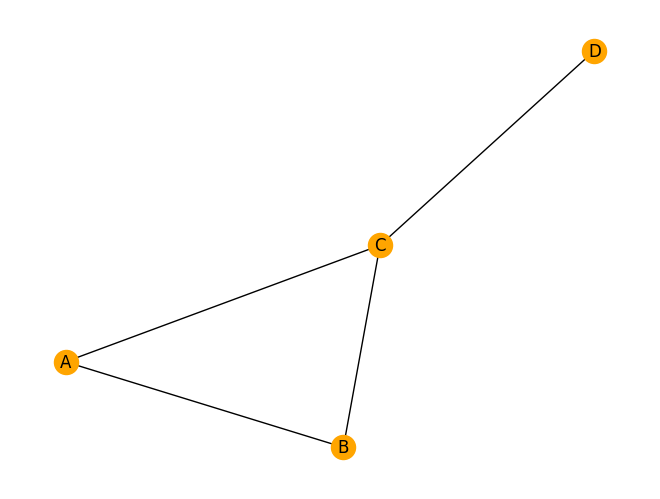

In [8]:
## 🔹 Visualize Triangles

nx.draw(G, with_labels=True, node_color='orange')
plt.show()


## 🧩 Summary & Key Takeaways

### 🔹 Core Algorithms Recap

**Connected Components**
* **What:** Groups of fully connected nodes
* **When:** Finding clusters, identifying fraud rings
* **How:** DFS/BFS traversal
* **Complexity:** O(V + E)
* **Key insight:** "Fraud rarely exists in isolation"

**Shortest Path (BFS + Dijkstra)**
* **What:** Minimum distance/cost between nodes
* **When:** Pathfinding, route optimization, risk distance
* **How:** BFS for unweighted, Dijkstra for weighted
* **Complexity:** O(V+E) for BFS, O((V+E) log V) for Dijkstra
* **Key insight:** "Find the most direct or economical connection"

**Triangle Count**
* **What:** Count of 3-node complete subgraphs
* **When:** Detecting collusion, measuring clustering
* **How:** Enumerate all node triplets
* **Complexity:** O(V^1.5) to O(E√E) depending on implementation
* **Key insight:** "Real networks have fewer triangles; fraud networks have more"

**Minimum Spanning Tree**
* **What:** Tree connecting all nodes with minimum total weight
* **When:** Infrastructure design, cost optimization
* **How:** Kruskal's or Prim's algorithm
* **Complexity:** O(E log E) to O(E + V log V)
* **Key insight:** "Connect everything with minimum cost"

---

### ⚖️ When to Use Which Algorithm

| Problem | Algorithm | Why This Works |
| --- | --- | --- |
| "Is account B connected to account A?" | Connected Components | Check if in same component |
| "What's the fastest/cheapest way from A to B?" | Shortest Path | Guaranteed to find optimal route |
| "Are these 4 accounts working together?" | Triangle Count | Tight clusters indicate coordination |
| "Build network with minimum infrastructure cost" | MST | Connects all with minimum weight |
| "How many hops from A to a fraud account?" | Shortest Path + distance | Immediate vs secondary risk |
| "Identify fraud rings" | Connected Components + Triangle Count | Components find rings, triangles find sub-rings |

---

### 🔥 Real-World Fraud Detection Pipeline

**Step 1:** Load transaction graph → All accounts and transactions
**Step 2:** Find connected components → Identify separate fraud rings
**Step 3:** Within each component, count triangles → Find tight collusion groups
**Step 4:** Calculate shortest paths → Understand how fraud spreads
**Step 5:** Flag high-risk patterns:
   - Multiple triangles = coordinated fraud
   - Short paths from known fraud = secondary spread
   - Isolated component = potential new ring

---

### 📊 Algorithm Complexity Reference

| Algorithm | Time | Space | Best Case | Worst Case |
| --- | --- | --- | --- | --- |
| Connected Components | O(V+E) | O(V) | Sparse graph | Dense graph |
| BFS Shortest Path | O(V+E) | O(V) | Small graph | Large graph |
| Dijkstra's Shortest Path | O((V+E)log V) | O(V) | Few edges | Many edges |
| Triangle Counting | O(V^1.5) | O(E) | Sparse | Dense |
| MST (Kruskal) | O(E log E) | O(E) | Sorted edges | Unsorted edges |

---

### 🧠 Mental Models Review

* **Connected Components** = "Find islands separated by water"
* **Shortest Path** = "Find the quickest route on a map"
* **Triangle Count** = "Measure how cliquish a group is"
* **MST** = "Connect cities with minimum roads"

---

### ❓ Key Questions to Ask

When analyzing a graph problem:

1. **"Do I need to find relationships?"** → Connected Components or Shortest Path
2. **"Do I need to measure closeness?"** → Triangle Count or Clustering Coefficient
3. **"Do I need to optimize cost?"** → MST or Shortest Path
4. **"Am I looking for patterns?"** → Triangle Count or Connected Components

---

### 🎯 Mini Exercises

Try to:

1. **Connected Components:** Create a graph with 3 components and verify the count
2. **Shortest Path:** Add a fourth edge to the graph and see how shortest paths change
3. **Triangle Count:** Find which node participates in the most triangles
4. **Combined:** Identify connected components, then find triangles within each

---

### 🚀 What's Next?

In the next notebook, we'll explore **centrality measures**:

* **Degree Centrality:** Who has the most connections?
* **Betweenness Centrality:** Who are the "bridges" connecting different groups?
* **Closeness Centrality:** Who is closest to everyone else?
* **Eigenvector Centrality:** Who is connected to important people?

These measures answer: **"Who are the most important nodes in the network?"**

This is critical for identifying **key fraudsters**, **influential users**, or **critical infrastructure nodes**.
